In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy.stats import spearmanr
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.svm import LinearSVR
from sklearn.model_selection import StratifiedKFold
from scipy.ndimage import gaussian_filter1d
from joblib import Parallel, delayed
import time as tm
import pickle

mne.set_log_level('WARNING')
%matplotlib inline

print(f'MNE version: {mne.__version__}')

MNE version: 1.12.0


In [3]:
# ruta raiz donde estan las carpetas de cada sujeto
data_dir = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/'

# sujetos disponibles
subjs_list = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d.startswith('s')
])
print(f'Sujetos encontrados ({len(subjs_list)}): {subjs_list}')

Sujetos encontrados (28): ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's0x', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']


In [4]:
# creamos listas vacías donde iremos guardando los datos de cada sujeto
all_main_epochs  = []
all_main_rawdata = []
subjs_ok         = []

for subject_id in subjs_list:
    subj_path = os.path.join(data_dir, subject_id)
    file_main = os.path.join(subj_path, 'main_epo.fif')

    # comprobamos que existe el archivo
    if not os.path.exists(file_main):
        print(f'  {subject_id}: falta main_epo.fif, se omite')
        continue

    try:
        main = mne.read_epochs(file_main, preload=True, verbose=False)

        all_main_epochs.append(main)
        all_main_rawdata.append({
            'epoch_dat': main.get_data(),  # array (n_trials × 32 × 2876)
            'metadata':  main.metadata     # tabla con deci, confi, rDV, nrep...
        })

        subjs_ok.append(subject_id)
        print(f'  {subject_id} cargado — shape: {main.get_data().shape}')

    except Exception as e:
        print(f'  {subject_id}: error al cargar → {e}')

nSubj  = len(subjs_ok)
time   = all_main_epochs[0].times  # vector de timepoints (2876,)
n_time = len(time)
print(f'\nTotal sujetos cargados: {nSubj}')
print(f'Timepoints: {n_time}  |  Ventana: {time[0]:.2f}s → {time[-1]:.2f}s')

  s01 cargado — shape: (250, 32, 2876)
  s02 cargado — shape: (261, 32, 2876)
  s03 cargado — shape: (256, 32, 2876)
  s04 cargado — shape: (236, 32, 2876)
  s05 cargado — shape: (243, 32, 2876)
  s06: falta main_epo.fif, se omite
  s07 cargado — shape: (249, 32, 2876)
  s08 cargado — shape: (247, 32, 2876)
  s09 cargado — shape: (193, 32, 2876)
  s0x: falta main_epo.fif, se omite
  s10 cargado — shape: (250, 32, 2876)
  s11 cargado — shape: (251, 32, 2876)
  s12 cargado — shape: (252, 32, 2876)
  s13 cargado — shape: (253, 32, 2876)
  s14 cargado — shape: (261, 32, 2876)
  s15 cargado — shape: (257, 32, 2876)
  s16 cargado — shape: (238, 32, 2876)
  s17 cargado — shape: (260, 32, 2876)
  s18 cargado — shape: (239, 32, 2876)
  s19 cargado — shape: (259, 32, 2876)
  s20 cargado — shape: (248, 32, 2876)
  s21 cargado — shape: (257, 32, 2876)
  s22 cargado — shape: (264, 32, 2876)
  s23 cargado — shape: (255, 32, 2876)
  s24 cargado — shape: (232, 32, 2876)
  s25 cargado — shape: (264, 32

In [5]:
# definimos las funciones auxiliares que usaran los clasificadores y regresores

# ── AngularRegression ─────────────────────────────────────────────────────────
# clasificador adaptado a orientaciones circulares — igual que en la notebook anterior
# convierte el angulo en cos(2θ) y sin(2θ) para manejar la simetria de los gratings (0° = 180°)
class AngularRegression(BaseEstimator, RegressorMixin):
    def __init__(self, clf=None):
        self.clf = clf if clf is not None else LinearSVR()

    def fit(self, X, y):
        self.clf_cos = clone(self.clf)
        self.clf_sin = clone(self.clf)
        self.clf_cos.fit(X, np.cos(2 * y))
        self.clf_sin.fit(X, np.sin(2 * y))
        return self

    def predict(self, X):
        cos_pred = self.clf_cos.predict(X)
        sin_pred = self.clf_sin.predict(X)
        return np.arctan2(sin_pred, cos_pred) / 2

# ── scorer_angle ──────────────────────────────────────────────────────────────
# mide que tan bien predijo el clasificador la orientacion
# usa la correlacion circular — resultado entre 0 (azar) y 1 (perfecto)
def scorer_angle(y_true, y_pred):
    error = 2 * y_true - 2 * y_pred
    return np.mean(np.cos(error))

# ── create_folds ──────────────────────────────────────────────────────────────
# crea 5 folds estratificados: cada fold tiene trials de todas las clases
# random_state=42 para que la division sea siempre la misma (reproducibilidad)
def create_folds(y_binned, n_folds=5):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    folds = []
    dummy_X = np.zeros(len(y_binned))
    for train_idx, test_idx in skf.split(dummy_X, y_binned):
        folds.append({'train_index': train_idx, 'test_index': test_idx})
    return folds

# ── decode_timepoint_deci ─────────────────────────────────────────────────────
# funcion que procesa un solo timepoint para decodificar la decision (deci)
# usa LDA como clasificador — se ejecutara en paralelo sobre todos los timepoints
def decode_timepoint_deci(it, Y, labels, folds):
    Ytime  = Y[:, :, it] # actividad de todos los trials en ese instante exacto
    scaler = StandardScaler().fit(Ytime) # estandariza los datos (media 0, desviacion estandar 1)
    Ytime  = scaler.transform(Ytime)
    preds  = np.full(len(labels), np.nan)
    clf    = LinearDiscriminantAnalysis()
    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue
        clf.fit(Ytime[train_ix], labels[train_ix]) # entrena con los trials de entrenamiento
        preds[test_ix] = clf.predict(Ytime[test_ix]) # predice los trials de test
    return preds

# ── decode_timepoint_spearman ─────────────────────────────────────────────────
# funcion que procesa un solo timepoint para decodificar confi o rDV
# usa correlacion de Spearman entre la actividad del EEG y la variable continua
# primero reduce los 32 canales a 1 dimension usando la norma L2 (magnitud del vector)
def decode_timepoint_spearman(it, Y, y_continuous):
    Ytime  = Y[:, :, it] # actividad de todos los trials en ese instante exacto
    scaler = StandardScaler().fit(Ytime) # estandariza los datos
    Ytime  = scaler.transform(Ytime)
    # reducimos los 32 canales a 1 dimension usando la norma L2
    # es decir, calculamos la magnitud del vector de actividad para cada trial
    eeg_magnitude = np.linalg.norm(Ytime, axis=1)  # (n_trials,)
    # calculamos la correlacion de Spearman entre la magnitud del EEG y la variable continua
    rho, _ = spearmanr(eeg_magnitude, y_continuous)
    return rho



subj s01 (1/26)
  deci decodificado  → 0.1 min transcurridos

subj s02 (2/26)
  deci decodificado  → 0.2 min transcurridos

subj s03 (3/26)
  deci decodificado  → 0.3 min transcurridos

subj s04 (4/26)
  deci decodificado  → 0.4 min transcurridos

subj s05 (5/26)
  deci decodificado  → 0.4 min transcurridos

subj s07 (6/26)
  deci decodificado  → 0.5 min transcurridos

subj s08 (7/26)
  deci decodificado  → 0.6 min transcurridos

subj s09 (8/26)
  deci decodificado  → 0.7 min transcurridos

subj s10 (9/26)
  deci decodificado  → 0.7 min transcurridos

subj s11 (10/26)
  deci decodificado  → 0.8 min transcurridos

subj s12 (11/26)
  deci decodificado  → 0.9 min transcurridos

subj s13 (12/26)
  deci decodificado  → 1.0 min transcurridos

subj s14 (13/26)
  deci decodificado  → 1.0 min transcurridos

subj s15 (14/26)
  deci decodificado  → 1.1 min transcurridos

subj s16 (15/26)
  deci decodificado  → 1.2 min transcurridos

subj s17 (16/26)
  deci decodificado  → 1.3 min transcurridos



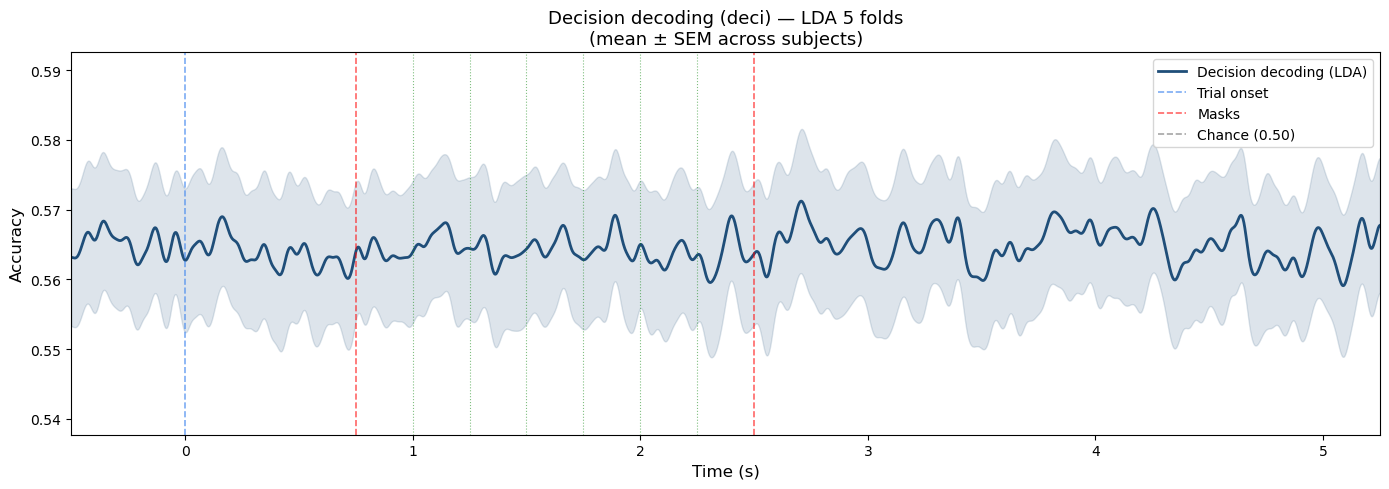

In [10]:
# ── DECODING DE LA DECISION (deci) — LDA con 5 folds ─────────────────────────
# queremos saber en que momento del trial el cerebro ya "sabe" que decision va a tomar
# deci es binaria: 0 = diagonal, 1 = cardinal
# usamos LDA como clasificador con 5 folds estratificados
# la metrica es accuracy (azar = 0.5 con 2 clases)

n_folds = 5

# array donde guardamos los resultados de accuracy (n_sujetos × n_timepoints)
scorer_deci = np.zeros((nSubj, n_time))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat'] # array (n_trials × 32 × 2876)
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    # labels: decision binaria (0 = diagonal, 1 = cardinal)
    labels = np.array(metadata['deci'], dtype=int)

    # creamos los 5 folds estratificados por la decision
    folds = create_folds(labels, n_folds)

    # procesamos todos los timepoints en paralelo usando todos los nucleos del Mac
    results_par = Parallel(n_jobs=-1)(
        delayed(decode_timepoint_deci)(it, Y, labels, folds)
        for it in range(n_time)
    )

    # convertimos la lista de arrays en una matriz (n_trials × n_time)
    preds_all = np.column_stack(results_par)

    # calculamos la accuracy para cada timepoint
    # accuracy = proporcion de trials donde el clasificador predijo la decision correcta
    for it in range(n_time):
        valid = ~np.isnan(preds_all[:, it])
        scorer_deci[isubj, it] = np.mean(
            preds_all[valid, it] == labels[valid].astype(float)
        )

    elapsed = (tm.time() - t_start) / 60
    print(f'  deci decodificado  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding de deci completado — shape: {scorer_deci.shape}')

# guardamos resultados
results_deci = {
    'scorer_deci': scorer_deci,
    'time':        time,
    'subjs_ok':    subjs_ok,
}

save_path_deci = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_deci.pkl'
with open(save_path_deci, 'wb') as f:
    pickle.dump(results_deci, f)

print(f'resultados guardados en: {save_path_deci}')

# plot 
sigma = 10
scorer_deci_smooth = gaussian_filter1d(scorer_deci, sigma=sigma, axis=1)
scorer_mean = np.mean(scorer_deci_smooth, axis=0)
scorer_sem  = np.std(scorer_deci_smooth, axis=0) / np.sqrt(nSubj)
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time, scorer_mean, color='#1f4e79', lw=2, label='Decision decoding (LDA)')
ax.fill_between(time, scorer_mean - scorer_sem, scorer_mean + scorer_sem,
                color='#1f4e79', alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.7, label='Chance (0.50)')


y_min = scorer_mean.min() - scorer_sem.max() - 0.01
y_max = scorer_mean.max() + scorer_sem.max() + 0.01
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])


ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding (deci) — LDA 5 folds\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

decoding de deci por nrep completado


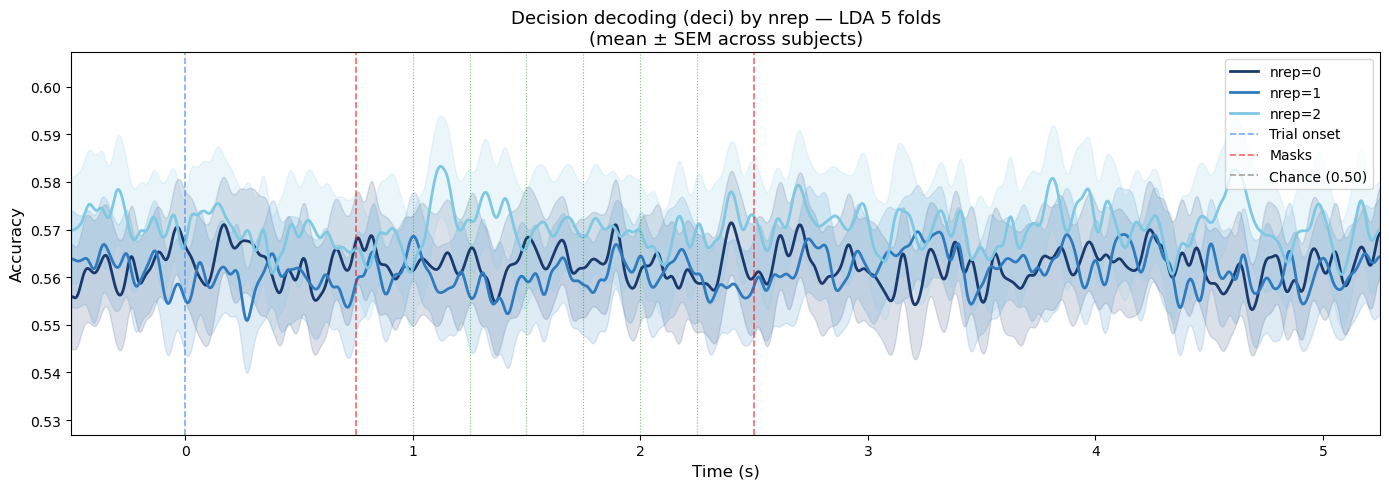

In [11]:
# ── DECODING DE LA DECISION (deci) POR NREP ──────────────────────────────────
# reutilizamos las predicciones ya calculadas en la celda anterior
# filtramos los trials por nrep y calculamos la accuracy para cada nrep por separado
# si el sesgo de confirmacion aumenta con las repeticiones, esperamos ver
# que la accuracy sube con nrep — especialmente antes de que se presenten los estimulos

nreps       = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']

# array donde guardamos los resultados por nrep (n_nreps × n_sujetos × n_timepoints)
scorer_deci_nrep = np.zeros((len(nreps), nSubj, n_time))

for isubj in range(nSubj):
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    labels   = np.array(metadata['deci'], dtype=int)

    # cargamos las predicciones ya calculadas para este sujeto
    preds = np.column_stack([
        decode_timepoint_deci(it,
                              all_main_rawdata[isubj]['epoch_dat'],
                              labels,
                              create_folds(labels, n_folds))
        for it in range(n_time)
    ])

    for i_nrep, nrep in enumerate(nreps):
        # indices de los trials con este nrep
        idx_nrep   = metadata[metadata['nrep'] == nrep].index.tolist()
        if len(idx_nrep) == 0:
            continue
        labels_nrep = labels[idx_nrep]
        preds_nrep  = preds[idx_nrep]

        # calculamos la accuracy para cada timepoint solo con los trials de este nrep
        for it in range(n_time):
            valid = ~np.isnan(preds_nrep[:, it])
            scorer_deci_nrep[i_nrep, isubj, it] = np.mean(
                preds_nrep[valid, it] == labels_nrep[valid].astype(float)
            )

print('decoding de deci por nrep completado')

# plot por nrep con escala adaptada
sigma = 10
scorer_deci_nrep_smooth = gaussian_filter1d(scorer_deci_nrep, sigma=sigma, axis=2)

fig, ax = plt.subplots(figsize=(14, 5))

for i_nrep, nrep in enumerate(nreps):
    mean = np.mean(scorer_deci_nrep_smooth[i_nrep], axis=0)
    sem  = np.std(scorer_deci_nrep_smooth[i_nrep], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean, color=colors_nrep[i_nrep], lw=2, label=f'nrep={nrep}')
    ax.fill_between(time, mean - sem, mean + sem,
                    color=colors_nrep[i_nrep], alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0.5, color='gray', ls='--', lw=1.2, alpha=0.7, label='Chance (0.50)')


all_means = np.array([
    np.mean(scorer_deci_nrep_smooth[i], axis=0) for i in range(len(nreps))
])
all_sems = np.array([
    np.std(scorer_deci_nrep_smooth[i], axis=0) / np.sqrt(nSubj) for i in range(len(nreps))
])

y_min = all_means.min() - all_sems.max() - 0.01
y_max = all_means.max() + all_sems.max() + 0.01
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding (deci) by nrep — LDA 5 folds\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()